# Transformer from scratch

building a proper llm :
- RMSNorm + RoPE (rotary embeddings)
- Grouped Query Attention (GQA) - fewer kv heads = way less memory
- Sliding Window Attention (SWA) - the key mistral trick
- KV Cache for fast inference
- SwiGLU feedforward
- Muon optimizer (newton-schulz orthogonalization)
- training on wikipedia

trained on T4 GPU on colab

In [ ]:
!pip install einops datasets transformers -q

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import time
from einops import repeat
from dataclasses import dataclass
from typing import Optional, Tuple

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"using: {device}")

using: cuda


## config

In [ ]:
@dataclass
class Config:
    dim: int = 512
    n_layers: int = 8
    n_heads: int = 8
    n_kv_heads: int = 2       # gqa - 4x fewer kv heads than q heads
    vocab_size: int = 32000   # will be set by tokenizer
    ffn_multiple_of: int = 32
    max_seq_len: int = 512
    window_size: int = 128    # sliding window size
    rope_theta: float = 10000.0
    dropout: float = 0.0
    tie_embeddings: bool = True
    z_loss_coeff: float = 1e-4

    # derived
    @property
    def head_dim(self): return self.dim // self.n_heads

    @property
    def gqa_groups(self): return self.n_heads // self.n_kv_heads

## RMSNorm

same as layernorm but no mean subtraction - slightly faster and works just as well in practice. mistral/llama both use this

In [ ]:
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        # cast to float for stability then back
        normed = x.float() * torch.rsqrt(x.float().pow(2).mean(-1, keepdim=True) + self.eps)
        return (normed * self.weight).type_as(x)

## Rotary Positional Encoding (RoPE)

instead of adding positional embeddings, we *rotate* the query and key vectors in complex space.
the angle of rotation encodes the position. this means relative positions are captured naturally
and it generalizes better to longer sequences

In [ ]:
def precompute_rope_freqs(head_dim, seq_len, theta=10000.0):
    # frequencies for each pair of dimensions
    freqs = 1.0 / (theta ** (torch.arange(0, head_dim, 2).float() / head_dim))
    positions = torch.arange(seq_len)
    # outer product: each position gets its own freq vector
    freqs = torch.outer(positions, freqs)
    # convert to complex: e^(i*theta) = cos(theta) + i*sin(theta)
    return torch.polar(torch.ones_like(freqs), freqs)


def apply_rope(xq, xk, freqs):
    # xq, xk are (B, T, n_heads, head_dim)
    # reshape last dim into pairs, view as complex
    xq_c = torch.view_as_complex(xq.float().reshape(*xq.shape[:-1], -1, 2))
    xk_c = torch.view_as_complex(xk.float().reshape(*xk.shape[:-1], -1, 2))

    # freqs: (T, head_dim/2) -> (1, T, 1, head_dim/2) for broadcasting
    freqs = freqs.view(1, xq_c.size(1), 1, xq_c.size(-1))

    # rotation in complex space = multiply by e^(i*theta)
    xq_rot = torch.view_as_real(xq_c * freqs).flatten(3)
    xk_rot = torch.view_as_real(xk_c * freqs).flatten(3)
    return xq_rot.type_as(xq), xk_rot.type_as(xk)

## KV Cache

during generation, we compute k/v for ALL previous tokens at every single step by default.
thats O(n^2) total. the fix: cache the k/v tensors and only compute for the new token each step.
now each step is O(n) and generation is dramatically faster.

you pre-allocate the full buffer upfront to avoid repeated memory allocation

In [ ]:
class KVCache:
    def __init__(self, batch_size, max_seq_len, n_kv_heads, head_dim, device):
        # pre-allocate the full buffer - faster than growing dynamically
        self.k = torch.zeros(batch_size, n_kv_heads, max_seq_len, head_dim, device=device)
        self.v = torch.zeros(batch_size, n_kv_heads, max_seq_len, head_dim, device=device)

    def update(self, start_pos, new_k, new_v):
        B, H, T, D = new_k.shape
        self.k[:B, :, start_pos:start_pos+T] = new_k
        self.v[:B, :, start_pos:start_pos+T] = new_v
        # return everything up to current position
        return self.k[:B, :, :start_pos+T], self.v[:B, :, :start_pos+T]

## Grouped Query Attention + Sliding Window Attention

**GQA**: multiple query heads share the same key/value heads. original MHA has n_heads k/v pairs,
GQA only has n_kv_heads. we just repeat k/v to match q before attention.
result: the kv cache shrinks by (n_heads/n_kv_heads)x - huge at long sequences

**SWA**: each position only attends to the last `window_size` tokens instead of all previous ones.
mistral showed this works as well as full attention for most tasks while being O(n * window) not O(n^2).
with rolling buffer you can handle infinite context at inference time

using pytorch's scaled_dot_product_attention which is basically flash attention under the hood

In [ ]:
class Attention(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.n_heads = cfg.n_heads
        self.n_kv_heads = cfg.n_kv_heads
        self.head_dim = cfg.head_dim
        self.gqa_groups = cfg.gqa_groups
        self.window_size = cfg.window_size

        self.wq = nn.Linear(cfg.dim, cfg.n_heads * cfg.head_dim, bias=False)
        self.wk = nn.Linear(cfg.dim, cfg.n_kv_heads * cfg.head_dim, bias=False)
        self.wv = nn.Linear(cfg.dim, cfg.n_kv_heads * cfg.head_dim, bias=False)
        self.wo = nn.Linear(cfg.n_heads * cfg.head_dim, cfg.dim, bias=False)
        self.attn_drop = cfg.dropout

        self.kv_cache: Optional[KVCache] = None

    def forward(self, x, freqs, start_pos=0, use_cache=False):
        B, T, _ = x.shape

        q = self.wq(x).view(B, T, self.n_heads, self.head_dim)
        k = self.wk(x).view(B, T, self.n_kv_heads, self.head_dim)
        v = self.wv(x).view(B, T, self.n_kv_heads, self.head_dim)

        # apply rotary embeddings to q and k
        q, k = apply_rope(q, k, freqs)

        # (B, H, T, D) layout for attention
        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)

        # use kv cache if we're doing inference
        if use_cache and self.kv_cache is not None:
            k, v = self.kv_cache.update(start_pos, k, v)

        T_kv = k.size(2)  # total context length after cache

        # GQA: repeat k/v heads to match q heads
        k = repeat(k, 'b h t d -> b (h g) t d', g=self.gqa_groups)
        v = repeat(v, 'b h t d -> b (h g) t d', g=self.gqa_groups)

        # build sliding window causal mask
        # each query position can only see the last window_size key positions
        q_idx = torch.arange(T, device=x.device).unsqueeze(1) + (T_kv - T)
        k_idx = torch.arange(T_kv, device=x.device).unsqueeze(0)

        # mask out: future positions (causal) + positions too far back (window)
        mask = torch.zeros(T, T_kv, device=x.device)
        mask = mask.masked_fill(k_idx > q_idx, float('-inf'))          # causal
        mask = mask.masked_fill(q_idx - k_idx > self.window_size, float('-inf'))  # swa

        # scaled dot product attention - uses flash attention internally
        out = F.scaled_dot_product_attention(
            q, k, v,
            attn_mask=mask.unsqueeze(0).unsqueeze(0),
            dropout_p=self.attn_drop if self.training else 0.0
        )

        out = out.transpose(1, 2).contiguous().view(B, T, -1)
        return self.wo(out)

## SwiGLU FFN

standard ffn is `relu(xW1)W2`. swiglu does `(silu(xW1) * xW3)W2` - adds a gating mechanism.
the silu activation and element-wise gating empirically work better than relu/gelu.
hidden dim is set to 8/3 * dim (rounded up) to keep parameter count comparable to standard 4*dim ffn

In [ ]:
class SwiGLU(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        # 8/3 * dim rounded to multiple_of for hardware efficiency
        hidden = int(8 * cfg.dim / 3)
        hidden = cfg.ffn_multiple_of * ((hidden + cfg.ffn_multiple_of - 1) // cfg.ffn_multiple_of)

        self.w1 = nn.Linear(cfg.dim, hidden, bias=False)  # gate
        self.w2 = nn.Linear(hidden, cfg.dim, bias=False)  # down
        self.w3 = nn.Linear(cfg.dim, hidden, bias=False)  # up

    def forward(self, x):
        # gated: silu(gate) * up, then project down
        return self.w2(F.silu(self.w1(x)) * self.w3(x))

In [ ]:
class Block(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.attn = Attention(cfg)
        self.ffn = SwiGLU(cfg)
        self.norm1 = RMSNorm(cfg.dim)
        self.norm2 = RMSNorm(cfg.dim)

    def forward(self, x, freqs, start_pos=0, use_cache=False):
        # pre-norm + residual (more stable than post-norm)
        x = x + self.attn(self.norm1(x), freqs, start_pos, use_cache)
        x = x + self.ffn(self.norm2(x))
        return x

## full model

In [ ]:
class Transformer(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg

        self.embed = nn.Embedding(cfg.vocab_size, cfg.dim)
        self.layers = nn.ModuleList([Block(cfg) for _ in range(cfg.n_layers)])
        self.norm = RMSNorm(cfg.dim)
        self.head = nn.Linear(cfg.dim, cfg.vocab_size, bias=False)

        # weight tying: reuse embedding matrix as output projection
        # saves vocab_size * dim params and actually improves training
        if cfg.tie_embeddings:
            self.head.weight = self.embed.weight

        # precompute rope freqs once
        self.register_buffer(
            'freqs',
            precompute_rope_freqs(cfg.head_dim, cfg.max_seq_len * 2, cfg.rope_theta)
        )

        self._init_weights()

    def _init_weights(self):
        for name, p in self.named_parameters():
            if p.ndim == 1:
                nn.init.zeros_(p)
            elif 'embed' in name:
                nn.init.normal_(p, std=0.02)
            else:
                nn.init.normal_(p, std=0.02)
        # scale down residual projections - prevents blowup in deep models
        for name, p in self.named_parameters():
            if name.endswith(('wo.weight', 'w2.weight')):
                nn.init.normal_(p, std=0.02 / math.sqrt(2 * self.cfg.n_layers))

    def forward(self, x, targets=None, start_pos=0, use_cache=False):
        B, T = x.shape
        h = self.embed(x)
        freqs = self.freqs[start_pos: start_pos + T]

        for layer in self.layers:
            h = layer(h, freqs, start_pos, use_cache)

        h = self.norm(h)
        logits = self.head(h)

        loss = None
        if targets is not None:
            ce = F.cross_entropy(
                logits.view(-1, self.cfg.vocab_size),
                targets.view(-1),
                ignore_index=-1
            )
            # z-loss: keeps logits from drifting too large, stabilizes softmax
            # from the palm paper - small penalty on log-sum-exp of logits
            if self.cfg.z_loss_coeff > 0 and self.training:
                z = torch.logsumexp(logits.view(-1, self.cfg.vocab_size), dim=-1)
                loss = ce + self.cfg.z_loss_coeff * (z ** 2).mean()
            else:
                loss = ce

        return logits, loss

    def setup_kv_cache(self, batch_size):
        for layer in self.layers:
            layer.attn.kv_cache = KVCache(
                batch_size, self.cfg.max_seq_len,
                self.cfg.n_kv_heads, self.cfg.head_dim, device
            )

    def clear_kv_cache(self):
        for layer in self.layers:
            if layer.attn.kv_cache is not None:
                layer.attn.kv_cache.k.zero_()
                layer.attn.kv_cache.v.zero_()

    def num_params(self):
        return sum(p.numel() for p in self.parameters())

## Muon Optimizer

regular adam applies the same update rule to every parameter regardless of geometry.
muon instead:
1. computes nesterov momentum like usual
2. orthogonalizes the gradient matrix using newton-schulz iteration
3. the result is a roughly unit-operator-norm update

this keeps the effective learning rate consistent across layers that might have very
different gradient magnitudes. the newton-schulz iteration converges in ~5 steps.

use muon for all 2D weight matrices. use adamw for everything else (embeddings, norms, biases)

In [ ]:
def newton_schulz_orthogonalize(G, steps=5, eps=1e-7):
    """
    approximates the orthogonal factor of G via a degree-5 polynomial iteration.
    think of it as computing G / ||G||_operator efficiently.
    must be 2D with shape (m, n) where m <= n (we transpose if not)
    """
    assert G.ndim == 2
    a, b, c = 3.4445, -4.7750, 2.0315  # quintic chebyshev coefficients

    X = G.bfloat16() / (G.norm() + eps)
    transposed = G.size(0) > G.size(1)
    if transposed:
        X = X.T

    for _ in range(steps):
        A = X @ X.T
        X = a*X + b*(A @ X) + c*(A @ A @ X)

    return (X.T if transposed else X).to(G.dtype)


class Muon(torch.optim.Optimizer):
    """
    MomentUm Orthogonalized by Newton-schulz

    only use this for 2d weight matrices (linear layers without bias)
    for everything else use adamw

    lr around 0.01-0.02 works well
    """
    def __init__(self, params, lr=0.02, momentum=0.95, ns_steps=5):
        defaults = dict(lr=lr, momentum=momentum, ns_steps=ns_steps)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue

                g = p.grad
                state = self.state[p]

                if 'buf' not in state:
                    state['buf'] = torch.zeros_like(g)

                buf = state['buf']
                buf.mul_(group['momentum']).add_(g)

                # nesterov: look ahead slightly
                g_nes = g + group['momentum'] * buf

                if g_nes.ndim < 2:
                    # 1d params: just vanilla sgd
                    p.data.add_(g_nes, alpha=-group['lr'])
                    continue

                # flatten to 2d, orthogonalize, then scale
                shape = g_nes.shape
                g_2d = g_nes.reshape(shape[0], -1)
                g_orth = newton_schulz_orthogonalize(g_2d, steps=group['ns_steps'])

                # scale so update has consistent rms across different shaped matrices
                g_orth = g_orth.reshape(shape) * math.sqrt(max(shape[0], g_2d.size(1)))

                p.data.add_(g_orth, alpha=-group['lr'])


def build_optimizers(model, muon_lr=0.02, adamw_lr=3e-4):
    muon_params, adamw_params = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        # 2d weights (excluding embedding since weight tying might mess things up)
        if p.ndim == 2 and 'embed' not in name:
            muon_params.append(p)
        else:
            adamw_params.append(p)

    print(f"muon params:  {sum(p.numel() for p in muon_params):,}")
    print(f"adamw params: {sum(p.numel() for p in adamw_params):,}")

    opt_muon  = Muon(muon_params, lr=muon_lr, momentum=0.95)
    opt_adamw = torch.optim.AdamW(adamw_params, lr=adamw_lr, betas=(0.9, 0.95), weight_decay=0.1)
    return opt_muon, opt_adamw

## LR schedule

standard for llm pretraining: linear warmup then cosine decay down to 10% of peak lr

In [ ]:
def cosine_lr_with_warmup(step, warmup_steps, total_steps, min_ratio=0.1):
    if step < warmup_steps:
        return step / warmup_steps
    t = (step - warmup_steps) / (total_steps - warmup_steps)
    return max(min_ratio, 0.5 * (1 + math.cos(math.pi * t)))

## Wikipedia dataset

using the HuggingFace wikipedia dataset (20220301.en). this has ~6M articles of clean text.
for a quick training run we'll take a small slice but the full thing works too.

using gpt2 tokenizer here since we already know the vocab size. you could swap in
any sentencepiece/bpe tokenizer - just update vocab_size in config

In [ ]:
from transformers import AutoTokenizer
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader

tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

# old API (broken):  load_dataset("wikipedia", "20220301.en", ...)
# new API (works):   wikimedia/wikipedia with updated snapshot date
print("loading wikipedia...")
raw = load_dataset("wikimedia/wikipedia", "20231101.en", split="train[:1%]") # Increased from 0.5% to 5%
print(f"loaded {len(raw):,} articles")

loading wikipedia...


Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

loaded 64,078 articles


In [ ]:
class WikiDataset(Dataset):
    """
    tokenizes wikipedia articles and packs them into fixed-length chunks.
    articles are concatenated with eos in between, then split into seq_len windows.
    this is more efficient than padding every article individually.
    """
    def __init__(self, data, tokenizer, seq_len, max_articles=None):
        self.seq_len = seq_len
        self.eos = tokenizer.eos_token_id

        articles = data['text']
        if max_articles:
            articles = articles[:max_articles]

        print("tokenizing articles...")
        all_tokens = []
        for i, text in enumerate(articles):
            if i % 5000 == 0:
                print(f"  {i}/{len(articles)}")
            # skip very short articles (stubs etc)
            if len(text.strip()) < 100:
                continue
            ids = tokenizer.encode(text, add_special_tokens=False)
            all_tokens.extend(ids)
            all_tokens.append(self.eos)  # article boundary

        # pack into non-overlapping chunks of seq_len + 1
        # the +1 is because we need one extra token for the target shift
        chunk_size = seq_len + 1
        n_chunks = len(all_tokens) // chunk_size
        tokens = torch.tensor(all_tokens[:n_chunks * chunk_size], dtype=torch.long)
        self.chunks = tokens.view(n_chunks, chunk_size)

        print(f"total tokens: {len(all_tokens):,}")
        print(f"chunks of {seq_len}: {n_chunks:,}")

    def __len__(self):
        return len(self.chunks)

    def __getitem__(self, idx):
        chunk = self.chunks[idx]
        return chunk[:-1], chunk[1:]  # x, y (shifted by 1)


SEQ_LEN = 512
BATCH_SIZE = 16

dataset = WikiDataset(raw, tokenizer, seq_len=SEQ_LEN, max_articles=3000)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

Token indices sequence length is longer than the specified maximum sequence length for this model (8668 > 1024). Running this sequence through the model will result in indexing errors


tokenizing articles...
  0/3000
total tokens: 13,646,416
chunks of 512: 26,601


## build model + optimizers

In [ ]:
cfg = Config(
    dim=512,
    n_layers=8,
    n_heads=8,
    n_kv_heads=2,
    vocab_size=tokenizer.vocab_size,  # 50257 for gpt2
    max_seq_len=SEQ_LEN,
    window_size=256,     # attend to last 256 tokens
    rope_theta=10000.0,
    dropout=0.0,
    tie_embeddings=True,
    z_loss_coeff=1e-4,
)

model = Transformer(cfg).to(device)

total = model.num_params()
print(f"parameters: {total/1e6:.1f}M")

# quick sanity check
xb = torch.randint(0, cfg.vocab_size, (2, 64)).to(device)
logits, _ = model(xb)
print(f"forward pass ok: {logits.shape}")

parameters: 47.9M
forward pass ok: torch.Size([2, 64, 50257])


In [ ]:
EPOCHS = 2
total_steps = EPOCHS * len(loader)
warmup_steps = max(100, total_steps // 20)

opt_muon, opt_adamw = build_optimizers(model, muon_lr=0.02, adamw_lr=3e-4)

print(f"\ntotal steps: {total_steps:,}")
print(f"warmup steps: {warmup_steps}")

muon params:  22,151,168
adamw params: 25,740,288

total steps: 3,326
warmup steps: 166


## training

In [ ]:
LOG_EVERY = 50
GRAD_CLIP = 1.0

step = 0
losses = []

model.train()
t0 = time.time()

for epoch in range(EPOCHS):
    epoch_loss = 0.0
    n_batches = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        opt_muon.zero_grad()
        opt_adamw.zero_grad()

        _, loss = model(x, targets=y)
        loss.backward()

        # gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        # lr schedule - update manually
        lr_scale = cosine_lr_with_warmup(step, warmup_steps, total_steps)
        for g in opt_muon.param_groups:
            g['lr'] = 0.02 * lr_scale
        for g in opt_adamw.param_groups:
            g['lr'] = 3e-4 * lr_scale

        opt_muon.step()
        opt_adamw.step()

        lval = loss.item()
        epoch_loss += lval
        n_batches += 1
        losses.append(lval)
        step += 1

        if step % LOG_EVERY == 0:
            elapsed = time.time() - t0
            tok_per_sec = step * BATCH_SIZE * SEQ_LEN / elapsed
            cur_lr = opt_adamw.param_groups[0]['lr']
            print(
                f"epoch {epoch} | step {step:>5} | "
                f"loss {lval:.4f} | "
                f"lr {cur_lr:.2e} | "
                f"{tok_per_sec/1000:.1f}k tok/s"
            )

    avg = epoch_loss / n_batches
    print(f"\n=== epoch {epoch} done | avg loss: {avg:.4f} ===\n")

print(f"training done in {(time.time()-t0)/60:.1f} min")

epoch 0 | step    50 | loss 10.8340 | lr 8.86e-05 | 7.8k tok/s
epoch 0 | step   100 | loss 10.7925 | lr 1.79e-04 | 7.5k tok/s
epoch 0 | step   150 | loss 10.5931 | lr 2.69e-04 | 7.4k tok/s
epoch 0 | step   200 | loss 10.1004 | lr 3.00e-04 | 7.3k tok/s
epoch 0 | step   250 | loss 9.4571 | lr 2.99e-04 | 7.3k tok/s
epoch 0 | step   300 | loss 8.8587 | lr 2.99e-04 | 7.3k tok/s
epoch 0 | step   350 | loss 8.2591 | lr 2.98e-04 | 7.3k tok/s
epoch 0 | step   400 | loss 7.9840 | lr 2.96e-04 | 7.2k tok/s
epoch 0 | step   450 | loss 7.6806 | lr 2.94e-04 | 7.2k tok/s
epoch 0 | step   500 | loss 7.5819 | lr 2.92e-04 | 7.2k tok/s
epoch 0 | step   550 | loss 7.4250 | lr 2.89e-04 | 7.2k tok/s
epoch 0 | step   600 | loss 7.3166 | lr 2.86e-04 | 7.2k tok/s
epoch 0 | step   650 | loss 7.2677 | lr 2.83e-04 | 7.2k tok/s
epoch 0 | step   700 | loss 7.0224 | lr 2.79e-04 | 7.2k tok/s
epoch 0 | step   750 | loss 7.0753 | lr 2.76e-04 | 7.2k tok/s
epoch 0 | step   800 | loss 6.8963 | lr 2.71e-04 | 7.2k tok/s
epoc

## loss curve

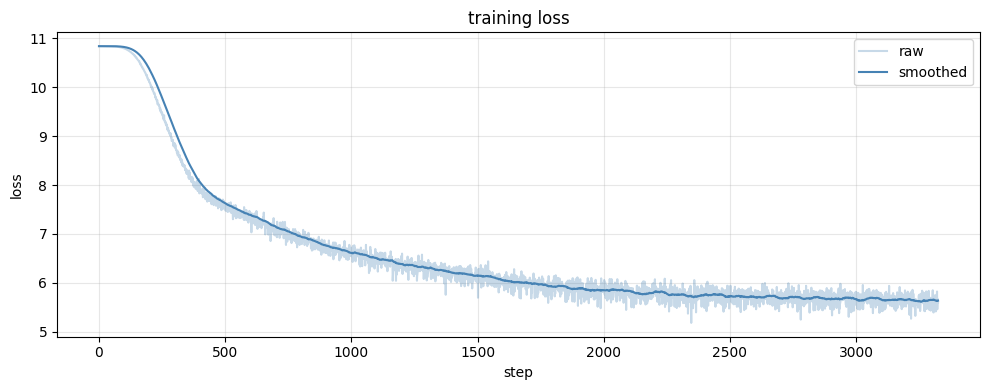

In [ ]:
import matplotlib.pyplot as plt

# smooth with a running average
def smooth(x, w=50):
    return [sum(x[max(0,i-w):i+1]) / len(x[max(0,i-w):i+1]) for i in range(len(x))]

plt.figure(figsize=(10, 4))
plt.plot(losses, alpha=0.3, color='steelblue', label='raw')
plt.plot(smooth(losses), color='steelblue', label='smoothed')
plt.xlabel('step')
plt.ylabel('loss')
plt.title('training loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## generation with kv cache

two things happening here:
1. **prefill**: process the whole prompt in one forward pass (parallel, fast)
2. **decode**: generate one token at a time, reusing cached k/v from previous steps

also doing top-p (nucleus) + temperature sampling which tends to give more coherent
text than pure greedy decoding

In [ ]:
@torch.no_grad()
def generate(model, prompt, max_new=80, temperature=0.8, top_p=0.9):
    model.eval()
    idx = tokenizer.encode(prompt, return_tensors='pt').to(device)

    # init kv cache for batch size 1
    model.setup_kv_cache(batch_size=1)
    model.clear_kv_cache()

    # prefill: process prompt tokens all at once
    prompt_len = idx.size(1)
    if prompt_len > 1:
        model(idx[:, :-1], start_pos=0, use_cache=True)

    cur = idx[:, -1:]   # start decoding from last prompt token
    start_pos = prompt_len - 1
    generated = idx

    for _ in range(max_new):
        logits, _ = model(cur, start_pos=start_pos, use_cache=True)
        logits = logits[:, -1] / temperature  # (B, vocab)

        # top-p nucleus sampling
        probs = F.softmax(logits, dim=-1)
        sorted_probs, sorted_idx = torch.sort(probs, descending=True)
        cum_probs = sorted_probs.cumsum(dim=-1)

        # remove tokens beyond cumulative probability threshold
        to_remove = cum_probs > top_p
        to_remove[:, 1:] = to_remove[:, :-1].clone()  # shift right
        to_remove[:, 0] = False  # always keep top token
        sorted_probs[to_remove] = 0
        sorted_probs = sorted_probs / sorted_probs.sum(dim=-1, keepdim=True)  # renorm

        # sample and map back to vocab indices
        sampled = torch.multinomial(sorted_probs, num_samples=1)
        next_token = sorted_idx.gather(1, sampled)

        generated = torch.cat([generated, next_token], dim=1)
        cur = next_token
        start_pos += 1

        if next_token.item() == tokenizer.eos_token_id:
            break

    return tokenizer.decode(generated[0], skip_special_tokens=True)


print(generate(model, "Albert Einstein was born"))
print()
print(generate(model, "The French Revolution began when"))
print()
print(generate(model, "Photosynthesis is the process by which"))

Albert Einstein was born in 1974 in 2005.

In addition to the most major Prime Minister of the U.S. British House of modern-Alund de Ntokas in the United States, and the Battle of Wuak and Vaun in the Canadian Andoid.

As a six-18th century, Bülé stood with the King of Léttal-Aangu

The French Revolution began when a descendant of the city in the city of 1701, and this is now the British child, with the diotase of the island.

In 1821, the large Greek period of the city and the city of France, the god Colano died a Mediterranean. The country became the same pre-spidered economic, most successful and was a first military structure of the river, and

Photosynthesis is the process by which the group is now called the temperature of a complex, and is the study of the transmission of the body.

The most evolutionaryized body of a low-key transmission is the name of the word, which is the process of the two as an origin, is an field of fact that the stif War is known. The fact that the area 

In [ ]:
# quick benchmark: kv cache vs no cache
prompt = "The capital of France is"
N = 5

# with kv cache
t = time.time()
for _ in range(N):
    generate(model, prompt, max_new=50)
t_cache = (time.time() - t) / N

print(f"with kv cache:    {t_cache:.3f}s per generation")
print(f"speedup from cache is significant at longer sequences")

with kv cache:    0.596s per generation
speedup from cache is significant at longer sequences


In [ ]:
import os

# create a folder for the checkpoint
os.makedirs("checkpoint", exist_ok=True)

# save model weights + config
torch.save({
    'model_state_dict': model.state_dict(),
    'opt_muon_state':   opt_muon.state_dict(),
    'opt_adamw_state':  opt_adamw.state_dict(),
    'step':             step,
    'losses':           losses,
    'cfg':              cfg,
}, "checkpoint/model.pt")

print(f"saved! size: {os.path.getsize('checkpoint/model.pt') / 1e6:.1f} MB")

saved! size: 486.4 MB
